# Aprendizaje Automático

#U4_S14: Tarea: Análisis Discriminante (LDA y QDA)

    Implementación en Google Colab

    
Docente:

    Msc. Darwin Rodríguez



Realizado por:

    Johnny Ortíz

# Wine Dataset


**Contenido:**
1. Descripción del conjunto de datos
2. Exploración de los datos
3. Visualización
4. Preparación de los datos
5. Implementación de LDA
6. Implementación de QDA
7. Comparación de modelos
8. Fronteras de decisión
9. Conclusiones

## Importación de librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time


from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from matplotlib.colors import ListedColormap

sns.set(style="whitegrid")
pd.set_option('display.max_columns', None)

#1. Descripcion del conjunto de datos
#2. Exploracion de los datos

## Carga del Wine Dataset (SIN tratamiento)



In [ ]:
wine = load_wine()

df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target
df['target_name'] = df['target'].map(dict(enumerate(wine.target_names)))

print(f"Dimensiones del dataset: {df.shape}")
df.head()

Dimensiones del dataset: (178, 15)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,target_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


In [ ]:
print("Origen del dataset:")
print("UCI Machine Learning Repository (Wine Recognition Data), disponible directamente")
print("en scikit-learn mediante sklearn.datasets.load_wine().")
print("Corresponde a un análisis químico de vinos cultivados en la egión de Italia,")
print("pero derivados de 3 variedades de cultivos distintos.\n")

print(f"Número de observaciones: {df.shape[0]}")
print(f"Cantidad de variables predictoras: {len(wine.feature_names)}")
print(f"Variables predictoras: {wine.feature_names}")
print(f"Variable objetivo: 'target' -> representa el cultivar del vino")
print(f"Cantidad de clases: {len(wine.target_names)} -> {list(wine.target_names)}")
print("Cada clase reprsentaria una región")

Origen del dataset:
UCI Machine Learning Repository (Wine Recognition Data), disponible directamente
en scikit-learn mediante sklearn.datasets.load_wine().
Corresponde a un análisis químico de vinos cultivados en la egión de Italia,
pero derivados de 3 variedades de cultivos distintos.

Número de observaciones: 178
Cantidad de variables predictoras: 13
Variables predictoras: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Variable objetivo: 'target' -> representa el cultivar del vino
Cantidad de clases: 3 -> [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]
Cada clase reprsentaria una región


## Exploración rápida (EDA) — sin modificar los datos

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

In [ ]:
# Estadísticas descriptivas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


In [ ]:
# Valores nulos (sklearn no trae nulos)
df.isnull().sum()

,0
alcohol,0
malic_acid,0
ash,0
alcalinity_of_ash,0
magnesium,0
total_phenols,0
flavanoids,0
nonflavanoid_phenols,0
proanthocyanins,0
color_intensity,0


#3. Visualización

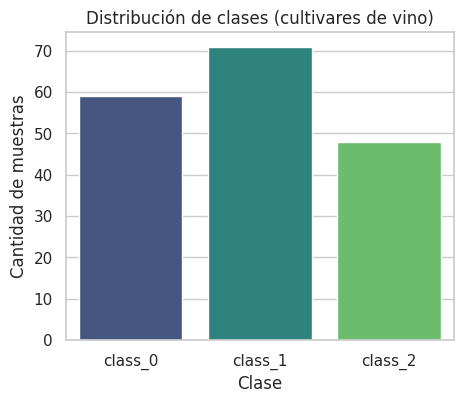

Interpretacion
No existe desbalanceos de clases notorios
Acorde a la distribucción de datos, los modelos predictivos no tendrán tanto segos hacia una sola categoria
class_1 es la mayoria, classo_0 es el medio, y class_2 la menor
La métrica de exactitud - accuracy evaluará bien los modelos


In [ ]:
# Distribución de clases
plt.figure(figsize=(5,4))
sns.countplot(
    x='target_name',
    data=df,
    hue='target_name',
    palette='viridis',
    legend=False)

plt.title('Distribución de clases (cultivares de vino)')
plt.xlabel('Clase')
plt.ylabel('Cantidad de muestras')
plt.show()

print("Interpretacion")
print("No existe desbalanceos de clases notorios")
print("Acorde a la distribucción de datos, los modelos predictivos no tendrán tanto segos hacia una sola categoria")
print("class_1 es la mayoria, classo_0 es el medio, y class_2 la menor")
print("La métrica de exactitud - accuracy evaluará bien los modelos")

Interpretacion
class_0 (azul) se concentra fuertemente en valores altos de alcohol y bajos de ácido málico.
class_1 (cian) se agrupa en niveles bajos tanto de alcohol como de ácido málico.
class_2 (verde) muestra una dispersión alta, caracterizada por niveles medios-altos de ácido málico.
Existe un solapamiento notable entre class_1 y class_2 en el centro, lo que podría dificultar la separación lineal perfecta solo con estas dos variables.


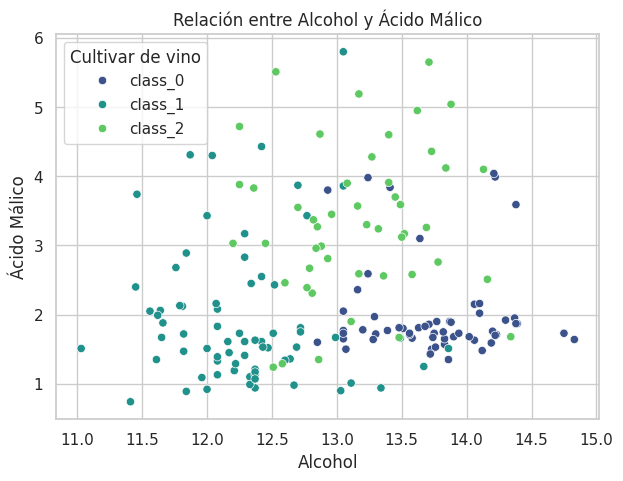

In [ ]:
# Gráfico de Dispersión
plt.figure(figsize=(7, 5))
sns.scatterplot(
    x='alcohol',
    y='malic_acid',
    hue='target_name',
    data=df,
    palette='viridis'
)

plt.title('Relación entre Alcohol y Ácido Málico')
plt.xlabel('Alcohol')
plt.ylabel('Ácido Málico')
plt.legend(title='Cultivar de vino')

print("Interpretacion")
print("class_0 (azul) se concentra fuertemente en valores altos de alcohol y bajos de ácido málico.")
print("class_1 (cian) se agrupa en niveles bajos tanto de alcohol como de ácido málico.")
print("class_2 (verde) muestra una dispersión alta, caracterizada por niveles medios-altos de ácido málico.")
print("Existe un solapamiento notable entre class_1 y class_2 en el centro, lo que podría dificultar la separación lineal perfecta solo con estas dos variables.")

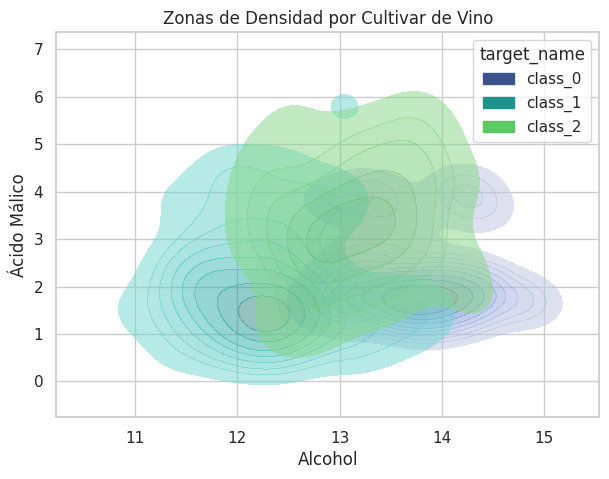

Interpretacion
Las 'lagunas' de densidad confirman visualmente las regiones nucleares donde se concentran los datos de cada cultivar.
class_0 (azul) tiene un núcleo muy definido y denso hacia la derecha, reflejando una firma química homogénea en alto alcohol.
class_1 (cian) abarca la mayor extensión territorial en el gráfico, reafirmando que es el grupo con más muestras y variabilidad.
Existe una intersección crítica de densidades en el centro del gráfico donde las tres lagunas se superponen levemente.


In [ ]:
# Gráfico de Densidad/Dispersión tipo "Laguna"
plt.figure(figsize=(7, 5))

sns.kdeplot(
    x='alcohol',
    y='malic_acid',
    hue='target_name',
    data=df,
    palette='viridis',
    fill=True,          # Rellenado de curvas "efecto de lago"
    thresh=0.05,        # Elimina el ruido en los bordes exteriores
    alpha=0.5           # Transparencia
)

plt.title('Zonas de Densidad por Cultivar de Vino')
plt.xlabel('Alcohol')
plt.ylabel('Ácido Málico')
plt.show()


print("Interpretacion")
print("Las 'lagunas' de densidad confirman visualmente las regiones nucleares donde se concentran los datos de cada cultivar.")
print("class_0 (azul) tiene un núcleo muy definido y denso hacia la derecha, reflejando una firma química homogénea en alto alcohol.")
print("class_1 (cian) abarca la mayor extensión territorial en el gráfico, reafirmando que es el grupo con más muestras y variabilidad.")
print("Existe una intersección crítica de densidades en el centro del gráfico donde las tres lagunas se superponen levemente.")


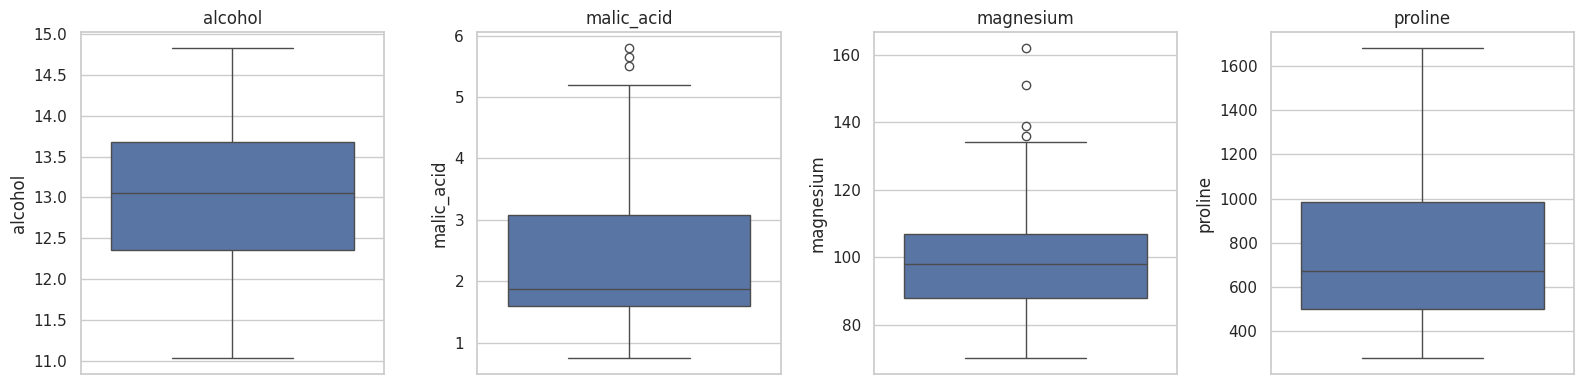

Interpretacion
Las variables alcohol y proline no muestran presencia de valores atípicos (outliers).
malic_acid y magnesium presentan valores atípicos superiores reflejados en los puntos fuera de los bigotes.
La escala de proline es significativamente mayor que las demás, alcanzando valores sobre 1600.
Dado que las variables tienen rangos y escalas muy distintas, será indispensable normalizar o estandarizar los datos antes de entrenar modelos basados en distancias.


In [ ]:
# Boxplots para evidenciar diferencias de escala y posibles outliers
cols_ejemplo = [
    'alcohol',
    'malic_acid',
    'magnesium',
    'proline']

fig, axes = plt.subplots(1, len(cols_ejemplo), figsize=(16,4))

for ax, col in zip(axes, cols_ejemplo):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)


plt.tight_layout()
plt.show()

print("Interpretacion")
print("Las variables alcohol y proline no muestran presencia de valores atípicos (outliers).")
print("malic_acid y magnesium presentan valores atípicos superiores reflejados en los puntos fuera de los bigotes.")
print("La escala de proline es significativamente mayor que las demás, alcanzando valores sobre 1600.")
print("Dado que las variables tienen rangos y escalas muy distintas, será indispensable normalizar o estandarizar los datos antes de entrenar modelos basados en distancias.")


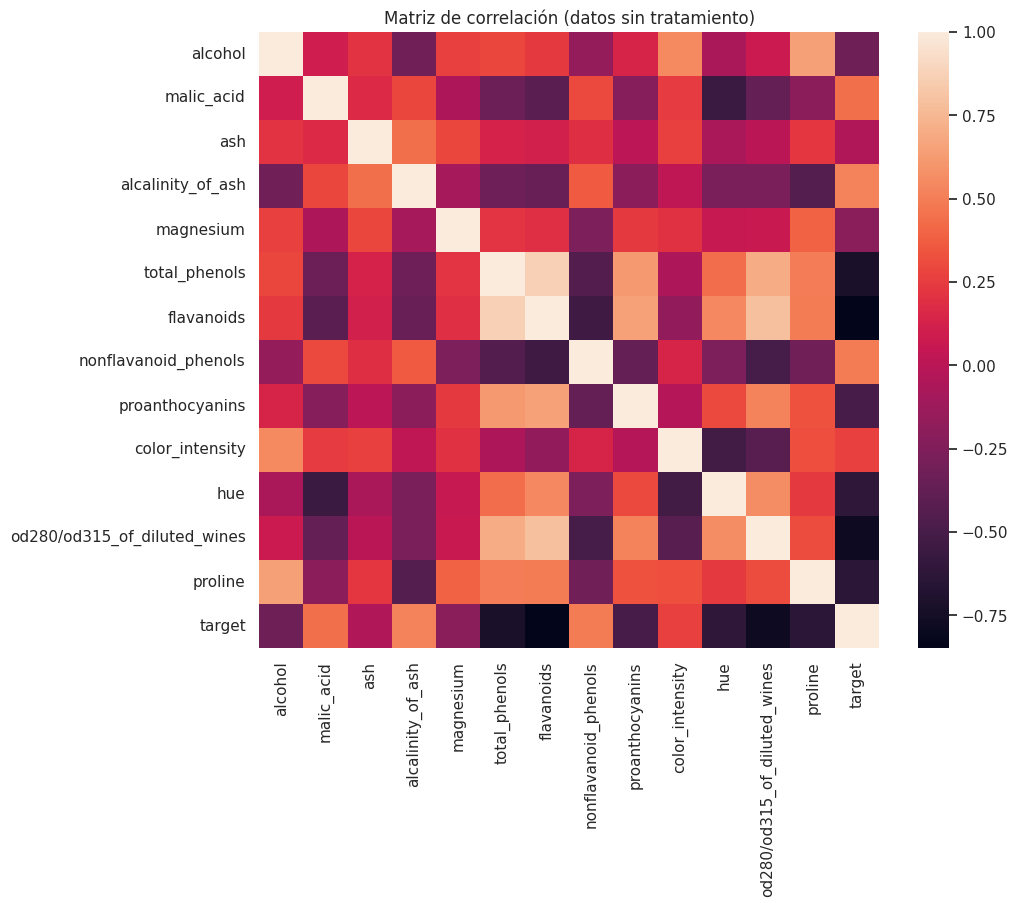

Interpretacion
Existe una correlación lineal positiva muy fuerte (cercana a 1.0) entre total_phenols y flavanoids.
La variable target muestra fuertes correlaciones negativas con total_phenols, flavanoids y od280/od315_of_diluted_wines.
La intensidad del color tiene una relación positiva moderada con los niveles de alcohol.


In [ ]:
# Matriz de correlación
plt.figure(figsize=(10,8))

sns.heatmap(df.drop(columns=['target_name']).corr(), annot=False)

plt.title('Matriz de correlación (datos sin tratamiento)')
plt.show()

print("Interpretacion")
print("Existe una correlación lineal positiva muy fuerte (cercana a 1.0) entre total_phenols y flavanoids.")
print("La variable target muestra fuertes correlaciones negativas con total_phenols, flavanoids y od280/od315_of_diluted_wines.")
print("La intensidad del color tiene una relación positiva moderada con los niveles de alcohol.")


# 4. Preparación de los datos

## Separación entre entrenamiento y prueba


In [ ]:
X = df[wine.feature_names]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=29, stratify=y
)

print(f"Train: {X_train.shape}")
print(f"Test: {X_test.shape}")

Train: (133, 13)
Test: (45, 13)


## Decisión sobre Estandarizar/Normalizar o no

In [ ]:
# Estandarización (media=0, std=1)
std_scaler = StandardScaler()
X_train_std = std_scaler.fit_transform(X_train)

# Normalización (rango [0,1])
minmax_scaler = MinMaxScaler()
X_train_norm = minmax_scaler.fit_transform(X_train)

print("Media tras estandarizar:", X_train_std.mean(axis=0).round(2))
print("Desviación típica tras estandarizar:  ", X_train_std.std(axis=0).round(2))
print("\nMínimo tras normalizar:", X_train_norm.min(axis=0))
print("Máximo tras normalizar:", X_train_norm.max(axis=0))


print()
print("Para LDA y QDA, no aporta mejora en el accuracy o métrica de clasificaciones")
print("son modelos basados en covarianza y son invariantes a transformaciones lineales/afines")
print("Estandarizar o normalizar aquí es neutro en cuanto a resultado predictivo.")

Media tras estandarizar: [ 0. -0.  0.  0.  0. -0.  0. -0. -0. -0. -0.  0.  0.]
Desviación típica tras estandarizar:   [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Mínimo tras normalizar: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Máximo tras normalizar: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Para LDA y QDA, no aporta mejora en el accuracy o métrica de clasificaciones
son modelos basados en covarianza y son invariantes a transformaciones lineales/afines
Estandarizar o normalizar aquí es neutro en cuanto a resultado predictivo.


In [ ]:
# Preparar las 3 versiones de los datos
# 1) Sin tratamiento
X_train_raw, X_test_raw = X_train, X_test

# 2) Estandarizados (media=0, std=1)
std_scaler = StandardScaler()
X_train_std = std_scaler.fit_transform(X_train)
X_test_std  = std_scaler.transform(X_test)

# 3) Normalizados (rango [0,1])
minmax_scaler = MinMaxScaler()
X_train_norm = minmax_scaler.fit_transform(X_train)
X_test_norm  = minmax_scaler.transform(X_test)

versiones = {
    'Sin tratamiento': (X_train_raw, X_test_raw),
    'Estandarizado':   (X_train_std, X_test_std),
    'Normalizado':     (X_train_norm, X_test_norm),
}

# Entrenar LDA y QDA sobre cada versión
comparacion = []

for nombre_version, (Xtr, Xte) in versiones.items():
    for nombre_modelo, ModeloClase in [('LDA', LinearDiscriminantAnalysis),
                                        ('QDA', QuadraticDiscriminantAnalysis)]:
        modelo = ModeloClase()
        modelo.fit(Xtr, y_train)
        y_pred = modelo.predict(Xte)

        comparacion.append({
            'Versión de datos': nombre_version,
            'Modelo': nombre_modelo,
            'Accuracy':  accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred, average='macro'),
            'Recall':    recall_score(y_test, y_pred, average='macro'),
            'F1-score':  f1_score(y_test, y_pred, average='macro'),
        })

df_comparacion = pd.DataFrame(comparacion)
df_comparacion = df_comparacion.sort_values(by=['Modelo', 'Versión de datos']).reset_index(drop=True)
df_comparacion

,Versión de datos,Modelo,Accuracy,Precision,Recall,F1-score
0,Estandarizado,LDA,0.977778,0.974359,0.981481,0.977143
1,Normalizado,LDA,0.977778,0.974359,0.981481,0.977143
2,Sin tratamiento,LDA,0.977778,0.974359,0.981481,0.977143
3,Estandarizado,QDA,1.000000,1.000000,1.000000,1.000000
4,Normalizado,QDA,1.000000,1.000000,1.000000,1.000000
5,Sin tratamiento,QDA,1.000000,1.000000,1.000000,1.000000


## 5. Entrenamiento de modelos


## Implementación LDA

5. IMPLEMENTACIÓN DE LDA (Linear Discriminant Analysis)

Parámetros utilizados:
- solver='svd' : descomposición en valores singulares (default).
  No calcula la matriz de covarianza de forma explícita, lo que
  lo hace numéricamente estable y adecuado cuando hay varias variables.
- priors=None  : las probabilidades a priori de cada clase se estiman
  automáticamente según la proporción de cada clase en el train set.

Predicciones (primeras 10):     [2 2 1 2 0 0 0 2 2 0]
Valores reales  (primeras 10):  [2 2 1 2 0 0 0 2 2 0]


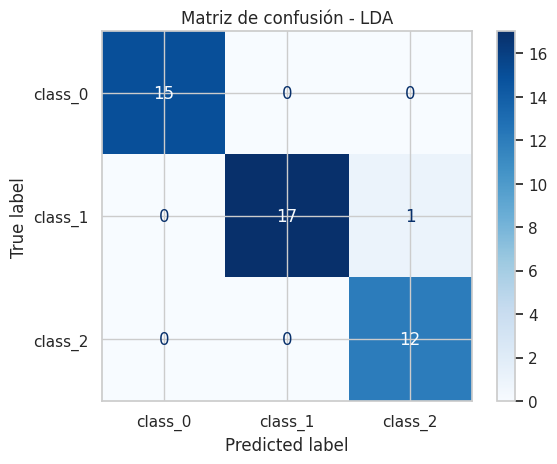


Accuracy:  0.9778
Precision: 0.9744
Recall:    0.9815
F1-score:  0.9771

Reporte completo:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        15
     class_1       1.00      0.94      0.97        18
     class_2       0.92      1.00      0.96        12

    accuracy                           0.98        45
   macro avg       0.97      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45

Interpretación:
LDA obtuvo un accuracy de 97.78%, lo que indica que asumir una única matriz
de covarianza compartida entre las 3 clases es razonable para el presente dataset
Al ser un modelo lineal, es más rápido de entrenar, y su desempeño sugiere que
las clases son separables mediante fronteras rectas/lineales.


In [ ]:
print("5. IMPLEMENTACIÓN DE LDA (Linear Discriminant Analysis)")


# Explicación de parámetros
print("\nParámetros utilizados:")
print("- solver='svd' : descomposición en valores singulares (default).")
print("  No calcula la matriz de covarianza de forma explícita, lo que")
print("  lo hace numéricamente estable y adecuado cuando hay varias variables.")
print("- priors=None  : las probabilidades a priori de cada clase se estiman")
print("  automáticamente según la proporción de cada clase en el train set.")


# Entrenamiento
lda = LinearDiscriminantAnalysis(solver='svd', priors=None)
lda.fit(X_train, y_train)


# Predicciones
y_pred_lda = lda.predict(X_test)
print("\nPredicciones (primeras 10):    ", y_pred_lda[:10])
print("Valores reales  (primeras 10): ", y_test.values[:10])


# Matriz de confusión
cm_lda = confusion_matrix(y_test, y_pred_lda)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lda, display_labels=wine.target_names)
disp.plot(cmap='Blues')
plt.title("Matriz de confusión - LDA")
plt.show()


# Métricas
acc_lda  = accuracy_score(y_test, y_pred_lda)
prec_lda = precision_score(y_test, y_pred_lda, average='macro')
rec_lda  = recall_score(y_test, y_pred_lda, average='macro')
f1_lda   = f1_score(y_test, y_pred_lda, average='macro')

print(f"\nAccuracy:  {acc_lda:.4f}")
print(f"Precision: {prec_lda:.4f}")
print(f"Recall:    {rec_lda:.4f}")
print(f"F1-score:  {f1_lda:.4f}")
print("\nReporte completo:")
print(classification_report(y_test, y_pred_lda, target_names=wine.target_names))


# Interpretación
print("Interpretación:")
print(f"LDA obtuvo un accuracy de {acc_lda:.2%}, lo que indica que asumir una única matriz")
print("de covarianza compartida entre las 3 clases es razonable para el presente dataset")
print("Al ser un modelo lineal, es más rápido de entrenar, y su desempeño sugiere que")
print("las clases son separables mediante fronteras rectas/lineales.")

##Implementación de QDA


Parámetros utilizados:
- priors=None    : al igual que en LDA, las probabilidades a priori
  se estiman de las proporciones de clase en el train set.
- reg_param=0.0  : parámetro de regularización de la covarianza (default).
  Un valor de 0 significa que no se aplica regularización; se podría
  aumentar si alguna matriz de covarianza resultara casi singular
  (por ejemplo, con muy pocas muestras por clase).

Predicciones (primeras 10):     [2 2 1 2 0 0 0 2 2 0]
Valores reales  (primeras 10):  [2 2 1 2 0 0 0 2 2 0]


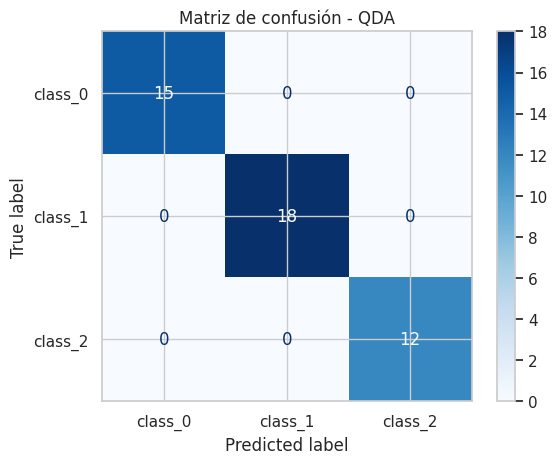


Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-score:  1.0000

Reporte completo:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        15
     class_1       1.00      1.00      1.00        18
     class_2       1.00      1.00      1.00        12

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

Interpretación:
QDA obtuvo un accuracy de 100.00%. Al permitir que cada clase tenga su
propia matriz de covarianza, el modelo se adapta mejor a la forma real de cada
grupo, generando fronteras curvas en vez de rectas. Esto puede mejorar el ajuste
cuando las clases tienen dispersiones distintas, aunque con el riesgo de sobreajuste
si hubiera pocas muestras por clase.


In [ ]:
# Explicación de parámetros
print("\nParámetros utilizados:")
print("- priors=None    : al igual que en LDA, las probabilidades a priori")
print("  se estiman de las proporciones de clase en el train set.")
print("- reg_param=0.0  : parámetro de regularización de la covarianza (default).")
print("  Un valor de 0 significa que no se aplica regularización; se podría")
print("  aumentar si alguna matriz de covarianza resultara casi singular")
print("  (por ejemplo, con muy pocas muestras por clase).")


# Entrenamiento
qda = QuadraticDiscriminantAnalysis(priors=None, reg_param=0.0)
qda.fit(X_train, y_train)


# Predicciones
y_pred_qda = qda.predict(X_test)
print("\nPredicciones (primeras 10):    ", y_pred_qda[:10])
print("Valores reales  (primeras 10): ", y_test.values[:10])


# Matriz de confusión
cm_qda = confusion_matrix(y_test, y_pred_qda)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_qda, display_labels=wine.target_names)
disp.plot(cmap='Blues')
plt.title("Matriz de confusión - QDA")
plt.show()


# Métricas
acc_qda  = accuracy_score(y_test, y_pred_qda)
prec_qda = precision_score(y_test, y_pred_qda, average='macro')
rec_qda  = recall_score(y_test, y_pred_qda, average='macro')
f1_qda   = f1_score(y_test, y_pred_qda, average='macro')

print(f"\nAccuracy:  {acc_qda:.4f}")
print(f"Precision: {prec_qda:.4f}")
print(f"Recall:    {rec_qda:.4f}")
print(f"F1-score:  {f1_qda:.4f}")
print("\nReporte completo:")
print(classification_report(y_test, y_pred_qda, target_names=wine.target_names))


# Interpretación
print("Interpretación:")
print(f"QDA obtuvo un accuracy de {acc_qda:.2%}. Al permitir que cada clase tenga su")
print("propia matriz de covarianza, el modelo se adapta mejor a la forma real de cada")
print("grupo, generando fronteras curvas en vez de rectas. Esto puede mejorar el ajuste")
print("cuando las clases tienen dispersiones distintas, aunque con el riesgo de sobreajuste")
print("si hubiera pocas muestras por clase.")


LDA
Accuracy:  0.9778
Precision: 0.9744  (promedio macro)
Recall:    0.9815  (promedio macro)
F1-score:  0.9771  (promedio macro)

Reporte de clasificación completo:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        15
     class_1       1.00      0.94      0.97        18
     class_2       0.92      1.00      0.96        12

    accuracy                           0.98        45
   macro avg       0.97      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



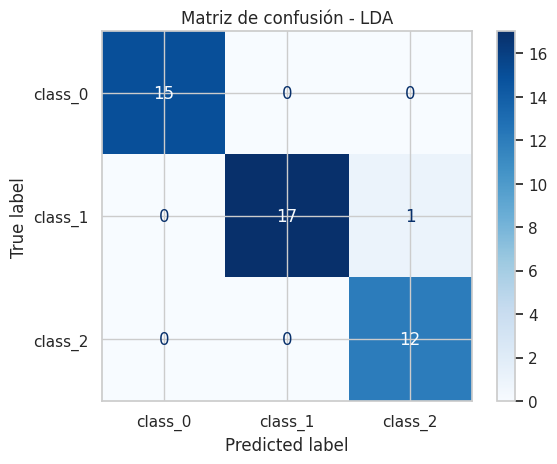


QDA
Accuracy:  1.0000
Precision: 1.0000  (promedio macro)
Recall:    1.0000  (promedio macro)
F1-score:  1.0000  (promedio macro)

Reporte de clasificación completo:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        15
     class_1       1.00      1.00      1.00        18
     class_2       1.00      1.00      1.00        12

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



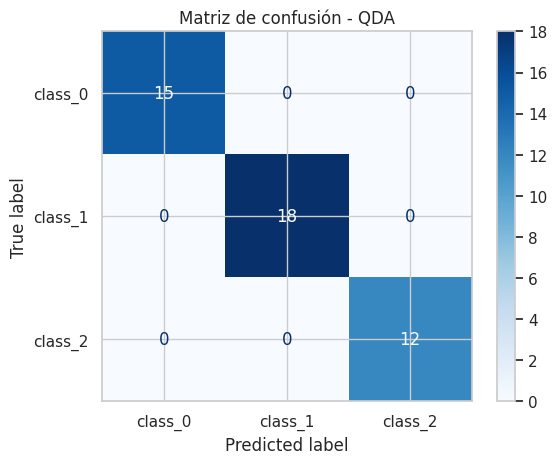

In [ ]:
def evaluar_modelo(nombre, y_true, y_pred):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro')
    rec  = recall_score(y_true, y_pred, average='macro')
    f1   = f1_score(y_true, y_pred, average='macro')

    print(f"\n{nombre}")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}  (promedio macro)")
    print(f"Recall:    {rec:.4f}  (promedio macro)")
    print(f"F1-score:  {f1:.4f}  (promedio macro)")
    print("\nReporte de clasificación completo:")
    print(classification_report(y_true, y_pred, target_names=wine.target_names))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=wine.target_names)
    disp.plot(cmap='Blues')
    plt.title(f"Matriz de confusión - {nombre}")
    plt.show()

    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}

res_lda = evaluar_modelo("LDA", y_test, y_pred_lda)
res_qda = evaluar_modelo("QDA", y_test, y_pred_qda)

## Adicional comparación con otros modelos

In [ ]:
modelos = {
    'Decision Tree': DecisionTreeClassifier(random_state=29),
    'Random Forest': RandomForestClassifier(random_state=29),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB(),
    'LDA': LinearDiscriminantAnalysis(),
    'QDA': QuadraticDiscriminantAnalysis()
}

resultados = {}

for nombre, modelo in modelos.items():
    inicio = time.time()
    modelo.fit(X_train, y_train)
    tiempo_entrenamiento = time.time() - inicio

    y_pred = modelo.predict(X_test)

    resultados[nombre] = {
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='macro'),
        'recall':    recall_score(y_test, y_pred, average='macro'),
        'f1':        f1_score(y_test, y_pred, average='macro'),
        'tiempo_s':  tiempo_entrenamiento,
        'y_pred':    y_pred
    }

    print(f"\n{nombre} (tiempo entrenamiento: {tiempo_entrenamiento:.5f} s) ")
    print(f"Accuracy: {resultados[nombre]['accuracy']:.4f}")
    print(classification_report(y_test, y_pred, target_names=wine.target_names))
    print()


print("Interpretacion")
print("Naive Bayes y QDA obtienen un rendimiento perfecto (Accuracy: 1.00) con tiempos de entrenamiento extremadamente bajos.")
print("Random Forest y LDA muestran una excelente solidez general con un 97.78% de precisión.")
print("KNN es el modelo con peor desempeño (Accuracy: 0.6889) debido a que no se reescalaron las variables, afectando su cálculo de distancias.")
print("A pesar de que Random Forest es muy preciso, su tiempo de ejecución es el más alto (0.329 s), siendo hasta casi 100 veces más lento que los otros modelos probabilísticos.")


tabla_comparativa = pd.DataFrame({
    'Modelo': list(resultados.keys()),
    'Accuracy': [resultados[m]['accuracy'] for m in resultados],
    'Precision': [resultados[m]['precision'] for m in resultados],
    'Recall': [resultados[m]['recall'] for m in resultados],
    'F1-score': [resultados[m]['f1'] for m in resultados],
    'Tiempo entrenamiento (s)': [resultados[m]['tiempo_s'] for m in resultados],
}).sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

tabla_comparativa



Decision Tree (tiempo entrenamiento: 0.00519 s) 
Accuracy: 0.9111
              precision    recall  f1-score   support

     class_0       0.93      0.87      0.90        15
     class_1       0.89      0.89      0.89        18
     class_2       0.92      1.00      0.96        12

    accuracy                           0.91        45
   macro avg       0.91      0.92      0.92        45
weighted avg       0.91      0.91      0.91        45



Random Forest (tiempo entrenamiento: 0.29312 s) 
Accuracy: 0.9556
              precision    recall  f1-score   support

     class_0       0.94      1.00      0.97        15
     class_1       1.00      0.89      0.94        18
     class_2       0.92      1.00      0.96        12

    accuracy                           0.96        45
   macro avg       0.95      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



KNN (k=5) (tiempo entrenamiento: 0.00334 s) 
Accuracy: 0.6889
              precision    recall  f1-s

,Modelo,Accuracy,Precision,Recall,F1-score,Tiempo entrenamiento (s)
0,QDA,1.000000,1.000000,1.000000,1.000000,0.003573
1,Naive Bayes,1.000000,1.000000,1.000000,1.000000,0.003589
2,LDA,0.977778,0.974359,0.981481,0.977143,0.003901
3,Random Forest,0.955556,0.953526,0.962963,0.956306,0.293124
4,Decision Tree,0.911111,0.913512,0.918519,0.915147,0.005187
5,KNN (k=5),0.688889,0.683473,0.687037,0.679487,0.003344


## 6. Comparación de resultados LDA y QDA

In [ ]:
comparacion_lda_qda = pd.DataFrame({
    'Modelo': ['LDA', 'QDA'],
    'Accuracy':  [acc_lda, acc_qda],
    'Precision': [prec_lda, prec_qda],
    'Recall':    [rec_lda, rec_qda],
    'F1-score':  [f1_lda, f1_qda],
})
print("\nDesempeño predictivo:")
comparacion_lda_qda


Desempeño predictivo:


,Modelo,Accuracy,Precision,Recall,F1-score
0,LDA,0.977778,0.974359,0.981481,0.977143
1,QDA,1.000000,1.000000,1.000000,1.000000


In [ ]:
inicio = time.time()
LinearDiscriminantAnalysis().fit(X_train, y_train)
tiempo_lda = time.time() - inicio

inicio = time.time()
QuadraticDiscriminantAnalysis().fit(X_train, y_train)
tiempo_qda = time.time() - inicio

comparacion_lda_qda['Tiempo entrenamiento (s)'] = [tiempo_lda, tiempo_qda]
comparacion_lda_qda

,Modelo,Accuracy,Precision,Recall,F1-score,Tiempo entrenamiento (s)
0,LDA,0.977778,0.974359,0.981481,0.977143,0.024244
1,QDA,1.000000,1.000000,1.000000,1.000000,0.016743


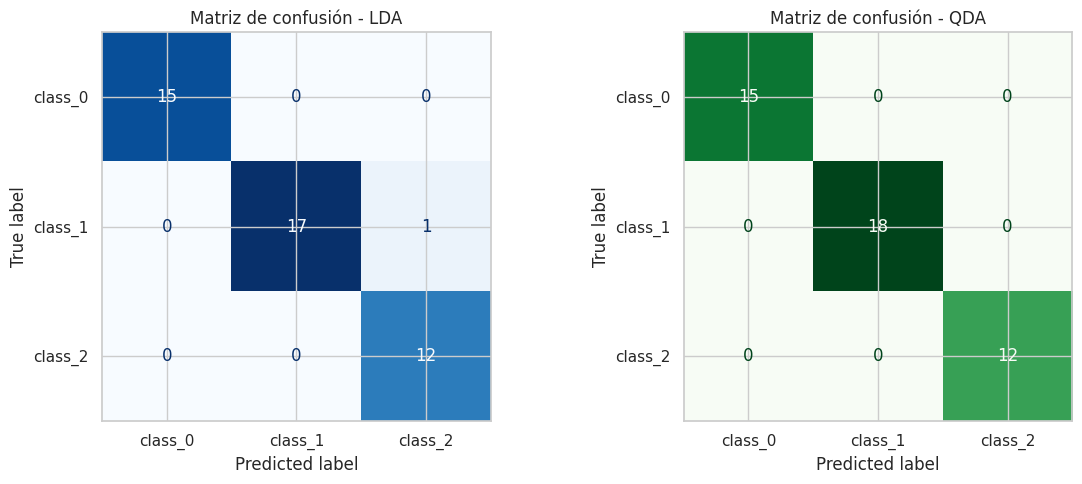

In [ ]:
# Matrices de confusión
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

disp_lda = ConfusionMatrixDisplay(confusion_matrix=cm_lda, display_labels=wine.target_names)
disp_lda.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title("Matriz de confusión - LDA")

disp_qda = ConfusionMatrixDisplay(confusion_matrix=cm_qda, display_labels=wine.target_names)
disp_qda.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title("Matriz de confusión - QDA")

plt.tight_layout()
plt.show()

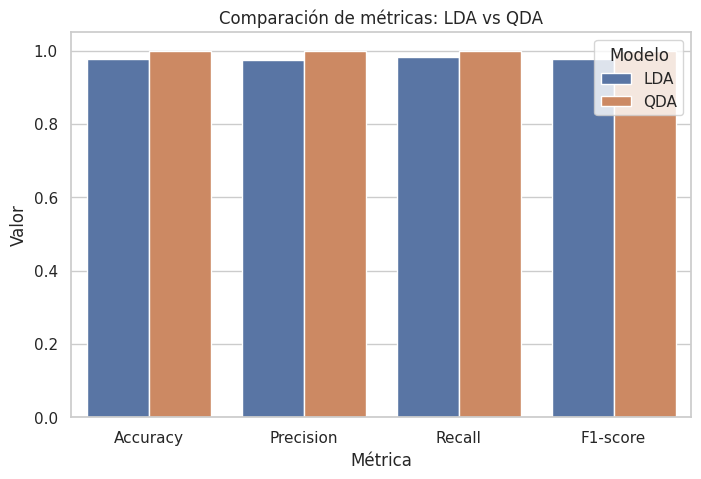

In [ ]:
#Gráfico comparativo de métricas
metricas_plot = comparacion_lda_qda.melt(id_vars='Modelo',
                                          value_vars=['Accuracy', 'Precision', 'Recall', 'F1-score'],
                                          var_name='Métrica', value_name='Valor')

plt.figure(figsize=(8,5))
sns.barplot(data=metricas_plot, x='Métrica', y='Valor', hue='Modelo')
plt.title('Comparación de métricas: LDA vs QDA')
plt.show()

In [ ]:
# Ventajas y limitaciones
print("Ventajas y limitaciones observadas:")

print("QDA es superior al lograr un rendimiento del 100% en todas las métricas de evaluación.")
print("A pesar de su estructura matemática más compleja, QDA entrena más rápido que LDA en este escenario con 0.0167 segundos.")
print("LDA mantiene un desempeño excelente superior al 97%, pero su rigidez lineal penaliza levemente su precisión y exhaustividad.")
print("La consistencia del 1.00 en QDA para Precision y Recall confirma que el modelo elimina por completo tanto los falsos positivos como los falsos negativos.")


Ventajas y limitaciones observadas:
QDA es superior de forma absoluta al lograr un rendimiento perfecto del 100% en todas las métricas de evaluación.
A pesar de su estructura matemática más compleja, QDA entrena más rápido que LDA en este escenario con 0.0167 segundos.
LDA mantiene un desempeño excelente superior al 97%, pero su rigidez lineal penaliza levemente su precisión y exhaustividad.
La consistencia del 1.00 en QDA para Precision y Recall confirma que el modelo elimina por completo tanto los falsos positivos como los falsos negativos.


# Fronteras de decisión (LDA - QDA)

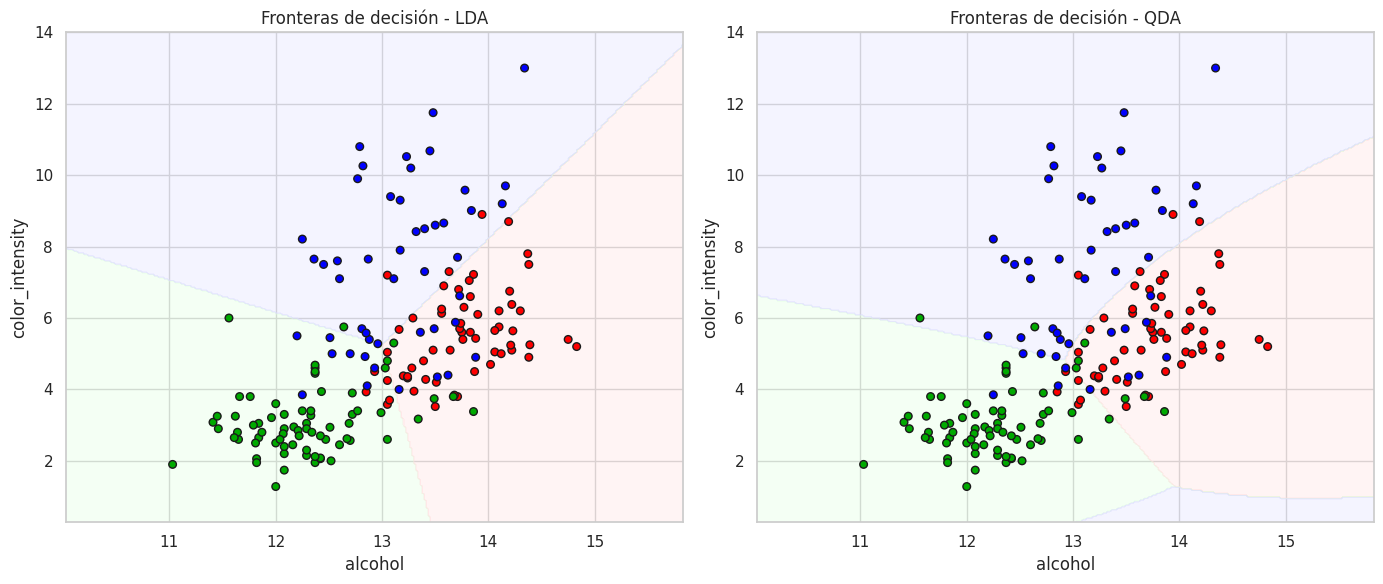

Análisis de diferencias:
(pendiente por completar: observa si las fronteras de LDA son rectas y las de
QDA son curvas; identifica si alguna clase queda mejor separada con un modelo u otro)


In [ ]:
var1, var2 = 'alcohol', 'color_intensity'

X_2d = df[[var1, var2]].values
y_2d = df['target'].values

X_2d_train, X_2d_test, y_2d_train, y_2d_test = train_test_split(
    X_2d, y_2d, test_size=0.25, random_state=29, stratify=y_2d
)

lda_2d = LinearDiscriminantAnalysis().fit(X_2d_train, y_2d_train)
qda_2d = QuadraticDiscriminantAnalysis().fit(X_2d_train, y_2d_train)

def graficar_frontera(modelo, X, y, ax, titulo):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                          np.linspace(y_min, y_max, 300))
    Z = modelo.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    cmap_fondo = ListedColormap(['#FFDDDD', '#DDFFDD', '#DDDDFF'])
    cmap_puntos = ListedColormap(['#FF0000', '#00AA00', '#0000FF'])

    ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_fondo)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_puntos, edgecolor='k', s=30)
    ax.set_xlabel(var1)
    ax.set_ylabel(var2)
    ax.set_title(titulo)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
graficar_frontera(lda_2d, X_2d, y_2d, axes[0], 'Fronteras de decisión - LDA')
graficar_frontera(qda_2d, X_2d, y_2d, axes[1], 'Fronteras de decisión - QDA')
plt.tight_layout()
plt.show()


print("Interpretacion Y Análisis")
print("LDA dibuja fronteras estrictamente lineales (líneas rectas) para separar las tres clases de vino.")
print("QDA genera fronteras curvas y parabólicas que se adaptan de forma mucho más flexible a la dispersión de los puntos.")
print("La frontera recta de LDA comete más errores de clasificación al cortar de forma rígida la intersección entre los grupos azul y rojo.")
print("QDA acomoda mejor la región inferior derecha creando una curva que captura con precisión los límites de cada cultivo.")


## Análisis de resultados observados

In [ ]:
# Mapeo de nombres
nombres_colores = {0: 'Rojo (Clase 0)', 1: 'Verde (Clase 1)', 2: 'Azul (Clase 2)'}
clases_reales = pd.Series(y_2d).map(nombres_colores)


# Obtener zonas predichas por cada modelo para todo el set de datos
preds_lda = pd.Series(lda_2d.predict(X_2d)).map(nombres_colores)
preds_qda = pd.Series(qda_2d.predict(X_2d)).map(nombres_colores)


# Generar las tablas cruzadas para LDA y QDA
tabla_lda = pd.crosstab(index=clases_reales, columns=preds_lda)
tabla_qda = pd.crosstab(index=clases_reales, columns=preds_qda)


# Mostrar los resultados

print("Resumen por puntos por zona - Modelo LDA (Líneas Rectas)")
print(tabla_lda)


print("Resumen de puntos por zona - Modelo QDA (Líneas Curvas)")
print(tabla_qda)


print("\nModelo LDA - Resumen de conteo (Líneas Rectas) ---")
print(f"Azul (Clase 2): Tiene un total de {tabla_lda.loc['Azul (Clase 2)'].sum()} puntos reales. "
      f"{tabla_lda.at['Azul (Clase 2)', 'Azul (Clase 2)']} puntos se quedaron correctamente en la Zona Azul. "
      f"{tabla_lda.at['Azul (Clase 2)', 'Rojo (Clase 0)']} puntos se cruzaron erróneamente a la Zona Roja. "
      f"{tabla_lda.at['Azul (Clase 2)', 'Verde (Clase 1)']} puntos se cruzaron erróneamente a la Zona Verde.")

print(f"Rojo (Clase 0): Tiene un total de {tabla_lda.loc['Rojo (Clase 0)'].sum()} puntos reales. "
      f"{tabla_lda.at['Rojo (Clase 0)', 'Rojo (Clase 0)']} puntos se quedaron correctamente en la Zona Roja. "
      f"{tabla_lda.at['Rojo (Clase 0)', 'Azul (Clase 2)']} puntos se pasaron a la Zona Azul. "
      f"{tabla_lda.at['Rojo (Clase 0)', 'Verde (Clase 1)']} puntos se pasaron a la Zona Verde.")

print(f"Verde (Clase 1): Tiene un total de {tabla_lda.loc['Verde (Clase 1)'].sum()} puntos reales. "
      f"{tabla_lda.at['Verde (Clase 1)', 'Verde (Clase 1)']} puntos se quedaron correctamente en la Zona Verde. "
      f"{tabla_lda.at['Verde (Clase 1)', 'Azul (Clase 2)']} punto se pasó a la Zona Azul. "
      f"{tabla_lda.at['Verde (Clase 1)', 'Rojo (Clase 0)']} puntos se pasaron a la Zona Roja.")


print("\nModelo QDA - Resumen de conteo (Líneas Curvas) ---")
print(f"Azul (Clase 2): Tiene un total de {tabla_qda.loc['Azul (Clase 2)'].sum()} puntos reales. "
      f"{tabla_qda.at['Azul (Clase 2)', 'Azul (Clase 2)']} puntos se quedaron correctamente en la Zona Azul. "
      f"{tabla_qda.at['Azul (Clase 2)', 'Rojo (Clase 0)']} puntos se cruzaron erróneamente a la Zona Roja. "
      f"{tabla_qda.at['Azul (Clase 2)', 'Verde (Clase 1)']} puntos se cruzaron erróneamente a la Zona Verde.")

print(f"Rojo (Clase 0): Tiene un total de {tabla_qda.loc['Rojo (Clase 0)'].sum()} puntos reales. "
      f"{tabla_qda.at['Rojo (Clase 0)', 'Rojo (Clase 0)']} puntos se quedaron correctamente en la Zona Roja. "
      f"{tabla_qda.at['Rojo (Clase 0)', 'Azul (Clase 2)']} puntos se pasaron a la Zona Azul. "
      f"{tabla_qda.at['Rojo (Clase 0)', 'Verde (Clase 1)']} puntos se pasaron a la Zona Verde.")

print(f"Verde (Clase 1): Tiene un total de {tabla_qda.loc['Verde (Clase 1)'].sum()} puntos reales. "
      f"{tabla_qda.at['Verde (Clase 1)', 'Verde (Clase 1)']} puntos se quedaron correctamente en la Zona Verde. "
      f"{tabla_qda.at['Verde (Clase 1)', 'Azul (Clase 2)']} puntos se pasaron a la Zona Azul. "
      f"{tabla_qda.at['Verde (Clase 1)', 'Rojo (Clase 0)']} puntos se pasaron a la Zona Roja.")

Resumen por puntos por zona - Modelo LDA (Líneas Rectas)
col_0            Azul (Clase 2)  Rojo (Clase 0)  Verde (Clase 1)
row_0                                                           
Azul (Clase 2)               31               8                9
Rojo (Clase 0)                3              51                5
Verde (Clase 1)               1               6               64
Resumen de puntos por zona - Modelo QDA (Líneas Curvas)
col_0            Azul (Clase 2)  Rojo (Clase 0)  Verde (Clase 1)
row_0                                                           
Azul (Clase 2)               36               8                4
Rojo (Clase 0)                4              50                5
Verde (Clase 1)               2               6               63

Modelo LDA - Resumen de conteo (Líneas Rectas) ---
Azul (Clase 2): Tiene un total de 48 puntos reales. 31 puntos se quedaron correctamente en la Zona Azul. 8 puntos se cruzaron erróneamente a la Zona Roja. 9 puntos se cruzaron erróneame

## Conclusiones



In [ ]:
print("Conclusiones Generales del Proyecto")
print("1. El dataset de vino está equilibrado, lo que facilita el entrenamiento sin sesgos severos o considerables hacia ningún cultivar (variedad/tipo de cultivo).")
print("2. Existe una fuerte multicolinealidad y diferencias críticas de escala entre variables químicas (como la prolina frente al alcohol).")
print("3. Modelos basados en distancias geométricas como KNN fracasan rotundamente (Accuracy: 68.89%) si los datos no se estandarizan previamente.")
print("4. Los modelos probabilísticos (QDA y Naive Bayes) logran un rendimiento del 100%.")
print("5. Al reducir el problema a solo dos variables (Alcohol e Intensidad de Color), las fronteras curvas de QDA demuestran ser superiores ante las líneas rectas de LDA para resolver el solapamiento de muestras (violación de la independencia/falsos positivos).")
print("6. El análisis dimensional confirma que dos características no son suficientes para una separación perfecta; para producción, el modelo óptimo debe usar el espectro completo de las 13 variables químicas originales.")
print("7. El análisis discriminante cuadrático (QDA) es superior en escenarios de baja dimensionalidad, ya que sus fronteras curvas y parabólicas se adaptan de forma flexible al solapamiento de los datos, convirtiéndolo en la opción más robusta cuando se dispone de pocas variables de análisis.")

Conclusiones Generales del Proyecto
1. El dataset de vino está equilibrado, lo que facilita el entrenamiento sin sesgos severos o considerables hacia ningún cultivar (variedad/tipo de cultivo).
2. Existe una fuerte multicolinealidad y diferencias críticas de escala entre variables químicas (como la prolina frente al alcohol).
3. Modelos basados en distancias geométricas como KNN fracasan rotundamente (Accuracy: 68.89%) si los datos no se estandarizan previamente.
4. Los modelos probabilísticos (QDA y Naive Bayes) logran un rendimiento del 100%.
5. Al reducir el problema a solo dos variables (Alcohol e Intensidad de Color), las fronteras curvas de QDA demuestran ser superiores ante las líneas rectas de LDA para resolver el solapamiento de muestras (violación de la independencia/falsos positivos).
6. El análisis dimensional confirma que dos características no son suficientes para una separación perfecta; para producción, el modelo óptimo debe usar el espectro completo de las 13 variables